In [2]:
import glob
import re
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.dates as mdates
from scipy.stats import linregress

In [3]:
# Fixed base directory
base_dir = "/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012"

# List of target subdirectories
dirs = [
    "b732-sep-15", "b733-sep-16", 
    "b734-sep-18", "b735-sep-19", "b736-sep-19", "b737-sep-20", "b738-sep-22", 
    "b739-sep-23", "b740-sep-25", "b741-sep-26", "b742-sep-27", "b743-sep-27", 
    "b744-sep-28", "b745-sep-28", "b746-sep-29", "b747-oct-01", "b748-oct-02", 
    "b749-oct-03", "b750-oct-03"
]

In [4]:
# Initialize a list to store file paths
file_paths = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/core_processed/core_faam*r1*.nc"
    file_paths.extend(sorted(glob.glob(path)))

# Print or use the collected file paths
#print(file_paths)

In [5]:
# List to store filtered file paths
filtered_files = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/core_processed/core_faam*r1*.nc"
    all_files = sorted(glob.glob(path))  # Get all r1 files
    
    # Print files found for debugging
    #print(f"Files found in {path}:")
    #print(all_files)
    
    # Filter out files that contain "_1hz"
    for file in all_files:
        if "_1hz" not in file:  # Exclude _1hz files
            filtered_files.append(file)

# Print or use the collected file paths
#print("\nFiltered files:")
#print(filtered_files)


In [6]:
# Initialize a list to store file paths
file_paths_ams = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/non-core/man-ams*.na"
    file_paths_ams.extend(sorted(glob.glob(path)))

# Print or use the collected file paths
#print(file_paths_ams)

In [7]:
# Initialize a list to store file paths
file_paths_sp2 = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/non-core/man-sp2*.na"
    file_paths_sp2.extend(sorted(glob.glob(path)))

# Print or use the collected file paths
#print(file_paths_sp2)

In [8]:
# Initialize a list to store file paths
file_paths_dry_neph = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/mo-non-core/metoffice*neph1*.nc"
    file_paths_dry_neph.extend(sorted(glob.glob(path)))

# Print or use the collected file paths
#print(file_paths_dry_neph)

In [9]:
# Initialize a list to store file paths
file_paths_dry_neph = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/mo-non-core/metoffice*neph1*.nc"
    file_paths_dry_neph.extend(sorted(glob.glob(path)))

# Print or use the collected file paths
#print(file_paths_dry_neph)

In [10]:
# Initialize a list to store file paths
file_paths_flight_sum = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/flight-sum*.txt"
    file_paths_flight_sum.extend(sorted(glob.glob(path)))

# Print or use the collected file paths
#print(file_paths_flight_sum)

In [11]:
# Function to extract flight number (e.g., "b734") from a file path
def extract_flight_number(file_path):
    match = re.search(r'b\d{3}', file_path)
    return match.group(0) if match else None  # Returns None if no match

# Get flight numbers for each dataset
flights_nc = {extract_flight_number(f) for f in filtered_files}
flights_ams = {extract_flight_number(f) for f in file_paths_ams}
flights_sp2 = {extract_flight_number(f) for f in file_paths_sp2}
flights_neph = {extract_flight_number(f) for f in file_paths_dry_neph}
flights_sum = {extract_flight_number(f) for f in file_paths_flight_sum}

# Find flights that are in all three datasets
common_flights = flights_nc & flights_ams & flights_sp2 & flights_neph & flights_sum # Set intersection

# Filter the file lists to include only matching flights
filtered_nc = [f for f in filtered_files if extract_flight_number(f) in common_flights]
filtered_ams = [f for f in file_paths_ams if extract_flight_number(f) in common_flights]
filtered_sp2 = [f for f in file_paths_sp2 if extract_flight_number(f) in common_flights]
filtered_neph = [f for f in file_paths_dry_neph if extract_flight_number(f) in common_flights]
filtered_sum = [f for f in file_paths_flight_sum if extract_flight_number(f) in common_flights]

# Print the results
print(f"Common flights: {sorted(common_flights)}")
print(f"Filtered NC files: {len(filtered_nc)}")
print(f"Filtered AMS files: {len(filtered_ams)}")
print(f"Filtered SP2 files: {len(filtered_sp2)}")
print(f"Filtered Neph files: {len(filtered_sp2)}")
print(f"Filtered Flight sum files: {len(filtered_sum)}")

Common flights: ['b734', 'b737', 'b739', 'b740', 'b741', 'b742', 'b743', 'b744', 'b745', 'b746', 'b747', 'b748', 'b749', 'b750']
Filtered NC files: 14
Filtered AMS files: 14
Filtered SP2 files: 14
Filtered Neph files: 14
Filtered Flight sum files: 14


In [12]:
filtered_sp2[0]

# Extract the date (format: yyyymmdd)
match = re.search(r'(\d{8})', filtered_sp2[0])

# Get the matched date or None if not found
flight_date = match.group(1) if match else None

print(flight_date)  # Output: 20120914

20120918


In [13]:
def convert_time_to_datetime_sp2(dsf, start_date_str):
    """
    Convert the 'Time_start_UTC' variable (seconds from 00:00 UTC) into datetime format.
    
    Parameters:
    - ds (xarray.Dataset): The dataset containing 'Time_start_UTC'
    - start_date_str (str): Start date in "YYYY MM DD" format
    
    Returns:
    - xarray.Dataset: Dataset with a new 'datetime' coordinate
    """
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    time_seconds = dsf["Time_UTC"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds])

    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))

    return dsf
    
def convert_time_to_datetime_ams(dsf, start_date_str):
    """
    Convert the 'Time_start_UTC' variable (seconds from 00:00 UTC) into datetime format.
    
    Parameters:
    - ds (xarray.Dataset): The dataset containing 'Time_start_UTC'
    - start_date_str (str): Start date in "YYYY MM DD" format
    
    Returns:
    - xarray.Dataset: Dataset with a new 'datetime' coordinate
    """
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    time_seconds = dsf["Time_start_UTC"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds])

    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))

    return dsf
    
def convert_time_to_datetime_neph(dsf, start_date_str):
    
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y%m%d")

    key_options = ["neph_spm", "NEPH_SPM"]  # Possible variations of the key
    matching_key = next((key for key in key_options if key in dsf), None)
    
    if matching_key:
        time_seconds = dsf[matching_key].values
    else:
        raise KeyError("Variable 'neph_spm' not found in dataset.")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    #time_seconds = dsf["neph_spm"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds])

    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("datetime", datetime_values))

    return dsf

In [14]:
def dataset_sp2_ams_neph(file_path_sp2,file_path_ams,file_path_neph):

    with open(file_path_sp2, "rb") as f:
        lines_sp2 = f.readlines()  # Read the first 100 bytes
    with open(file_path_ams, "rb") as f:
        lines_ams = f.readlines()  # Read the first 100 bytes
        
    metadata_lines_sp2 = lines_sp2[:39]  # 39 lines are metadata
    header_line_sp2 = metadata_lines_sp2[38].strip().split()  # Extract header names
    # Decode if header contains byte strings
    header_line_sp2 = [h.decode("utf-8") if isinstance(h, bytes) else h for h in header_line_sp2]
    # Decode if metadata contains byte strings
    metadata_lines_sp2 = [line.decode("utf-8").strip() if isinstance(line, bytes) else line.strip() for line in metadata_lines_sp2]
    #print(header_line_sp2)

    metadata_lines_ams = lines_ams[:46]   # 46 lines are metadata
    header_line_ams = metadata_lines_ams[45].strip().split()  # Extract header names
    # Decode if header contains byte strings
    header_line_ams = [h.decode("utf-8") if isinstance(h, bytes) else h for h in header_line_ams]
    # Decode if metadata contains byte strings
    metadata_lines_ams = [line.decode("utf-8").strip() if isinstance(line, bytes) else line.strip() for line in metadata_lines_ams]
    #print(header_line_ams)

    data_lines_sp2 = lines_sp2[39:]  # Actual data starts after metadata
    data_lines_ams = lines_ams[46:]
    
    # Parse data into a NumPy array
    data_array = np.array([line.strip().split() for line in data_lines_sp2], dtype=float)
    
    # Define dimensions (assuming first column is time and others are variables)
    dims = ("time", "variable")  # Modify as needed
    time_coords = np.arange(data_array.shape[0])  # Placeholder for time index
    
    # Convert to xarray Dataset with headers as variable names
    ds0_sp2 = xr.Dataset(
        {name: ("time", data_array[:, i]) for i, name in enumerate(header_line_sp2)},
        coords={"time": time_coords},
        attrs={"Metadata": "\n".join(metadata_lines_sp2[:38])}  # Store metadata as an attribute
    )
    
    # Parse data into a NumPy array
    data_array = np.array([line.strip().split() for line in data_lines_ams], dtype=float)
    
    # Define dimensions (assuming first column is time and others are variables)
    dims = ("time", "variable")  # Modify as needed
    time_coords = np.arange(data_array.shape[0])  # Placeholder for time index
    
    # Convert to xarray Dataset with headers as variable names
    ds0_ams = xr.Dataset(
        {name: ("time", data_array[:, i]) for i, name in enumerate(header_line_ams)},
        coords={"time": time_coords},
        attrs={"Metadata": "\n".join(metadata_lines_ams[:45])}  # Store metadata as an attribute
    )
 
    # Extract the date (format: yyyymmdd)
    match_sp2 = re.search(r'(\d{8})', file_path_sp2)
    # Get the matched date or None if not found
    flight_date_sp2 = match_sp2.group(1) if match_sp2 else None

    # Extract the date (format: yyyymmdd)
    match_ams = re.search(r'(\d{8})', file_path_ams)
    # Get the matched date or None if not found
    flight_date_ams = match_ams.group(1) if match_ams else None


    ds_neph = xr.open_dataset(file_path_neph,decode_times=False)

    # Extract the date (format: yyyymmdd)
    match_neph = re.search(r'(\d{8})', file_path_neph)
    # Get the matched date or None if not found
    flight_date_neph = match_neph.group(1) if match_neph else None
    
    # Convert time
    ds0_sp2 = convert_time_to_datetime_sp2(ds0_sp2, flight_date_sp2)
    ds0_ams = convert_time_to_datetime_ams(ds0_ams, flight_date_ams)
    ds_neph = convert_time_to_datetime_neph(ds_neph, flight_date_neph)
    
    #TM,AD= calculate_total_mass(ds_sp2,ds_ams)

    return ds0_sp2,ds0_ams,ds_neph

In [15]:
def Area_plot(aux_ds_sp2,aux_ds_ams,aux_ds_psap):
    # Filter out invalid BC mass values (9999999)
    valid_BC_mass_mask = aux_ds_sp2["BC_mass"] != 9999999
    filtered_ds_BC_mass = aux_ds_sp2.where(valid_BC_mass_mask, drop=True)
    
    # Filter out invalid SO4 values (9999999)
    valid_SO4_mask = aux_ds_ams["SO4"] != 9999999
    filtered_ds_SO4 = aux_ds_ams.where(valid_SO4_mask, drop=True)
    
    # Filter out invalid NH4 values (9999999)
    valid_NH4_mask = aux_ds_ams["NH4"] != 9999999
    filtered_ds_NH4 = aux_ds_ams.where(valid_NH4_mask, drop=True)
    
    # Filter out invalid ORG values (9999999)
    valid_ORG_mask = aux_ds_ams["ORG"] != 9999999
    filtered_ds_ORG = aux_ds_ams.where(valid_ORG_mask, drop=True)
    
    # Filter out invalid NO3 values (9999999)
    valid_NO3_mask = aux_ds_ams["NO3"] != 9999999
    filtered_ds_NO3 = aux_ds_ams.where(valid_NO3_mask, drop=True)
    
    
    # Filter out invalid Chl values (9999999)
    valid_Chl_mask = aux_ds_ams["Chl"] != 9999999
    filtered_ds_Chl = aux_ds_ams.where(valid_Chl_mask, drop=True)
    
    # Convert BC_mass from ng/m³ to µg/m³ (1 ng = 0.001 µg)
    filtered_ds_BC_mass["BC_mass_ug"] = filtered_ds_BC_mass["BC_mass"] * 1e-3
    
    # Interpolate BC_mass_ug to match the timestamps of filtered_ds_SO4
    bc_mass_interp = np.interp(
        filtered_ds_SO4.datetime.astype('int64'),   # Target time (SO4)
        filtered_ds_BC_mass.datetime.astype('int64'), # Original BC_mass time
        filtered_ds_BC_mass["BC_mass_ug"] # Original BC_mass values
    )

    # Compute total mass concentration
    total_mass = (
        bc_mass_interp + 
        filtered_ds_SO4["SO4"] +
        filtered_ds_NH4["NH4"] +
        filtered_ds_ORG["ORG"] +
        filtered_ds_NO3["NO3"] +
        filtered_ds_Chl["Chl"]
    )
    
    # Define time axis (assuming all datasets have the same time dimension)
    time = total_mass.datetime.values
    
    # Extract variables
    bc_mass = bc_mass_interp
    so4 = filtered_ds_SO4["SO4"]
    nh4 = filtered_ds_NH4["NH4"]
    org = filtered_ds_ORG["ORG"]
    no3 = filtered_ds_NO3["NO3"]
    chl = filtered_ds_Chl["Chl"]

    
    #filtered_time = total_mass.datetime.values  # Reference timestamps
    #psap_time = aux_ds_psap["Time"].values  # Original timestamps from new dataset
    
    # Stack the values
    data = [bc_mass, so4, nh4, org, no3, chl]
    
    return time,data


In [16]:
def Test_function(aux_ds_ams,aux_ds_psap,aux_ds_sp2):
    # List of variables to check for invalid values
    variables = ["SO4", "NH4", "ORG", "NO3","Chl"]
    components = ["BC_mass"]

    #(aux_ds_sp2["BC_mass"] != 9999999) & (aux_ds_sp2["BC_mass"] >= 0)
    # Build a combined valid mask using xarray operations
    valid_mask = (aux_ds_ams[variables[0]] != 9999999) & (aux_ds_ams[variables[0]] >= 0)
    for var in variables[1:]:
        valid_mask = valid_mask & (aux_ds_ams[var] != 9999999)  & (aux_ds_ams[var]  >= 0)
    
    # Apply the combined mask to the whole dataset
    filtered_ds = aux_ds_ams.where(valid_mask, drop=True)

    # Filter out invalid BC mass values (9999999)
    valid_BC_mass_mask = aux_ds_sp2["BC_mass"] != 9999999
    filtered_ds_BC_mass = aux_ds_sp2.where(valid_BC_mass_mask, drop=True)
    # Convert BC_mass from ng/m³ to µg/m³ (1 ng = 0.001 µg)
    filtered_ds_BC_mass["BC_mass"] = filtered_ds_BC_mass["BC_mass"] * 1e-3

    valid_PSAP_mask = aux_ds_psap['PSAP_LIN_FLAG'] == 0
    filtered_psap = aux_ds_psap.where(valid_PSAP_mask, drop=True)

    # Resample to 1-minute means
    resampled_ds = filtered_ds.resample(datetime="1min").mean()
    resampled_psap = filtered_psap.resample(Time='1min').mean()
    resampled_ds_sp2 = filtered_ds_BC_mass.resample(datetime="1min").mean()

    #print(resampled_ds['time'].shape)
    #print(resampled_ds_sp2['BC_mass'].shape)

    # Calculate total mass across selected components
    total_mass_ams = sum(resampled_ds[var] for var in variables)
    #print(total_mass_ams)
    total_mass_bc = sum(resampled_ds_sp2[var] for var in components)
    #print(total_mass)
    total_mass = total_mass_ams + total_mass_bc
    #print(total_mass)
    # Compute mass fractions and store in a new dataset
    mass_fraction_ds_ams = xr.Dataset({
        f"{var}_fraction": resampled_ds[var] / total_mass
        for var in variables
    })

    for var in variables:
        mass_fraction_ds_ams[f"{var}_fraction"].attrs["units"] = "unitless"
        mass_fraction_ds_ams[f"{var}_fraction"].attrs["description"] = f"Mass fraction of {var}"
    
    # Compute mass fractions and store in a new dataset
    mass_fraction_ds_sp2 = xr.Dataset({
        f"{var}_fraction": resampled_ds_sp2[var] / total_mass
        for var in components
    })

    for var in components:
        mass_fraction_ds_sp2[f"{var}_fraction"].attrs["units"] = "unitless"
        mass_fraction_ds_sp2[f"{var}_fraction"].attrs["description"] = f"Mass fraction of {var}"
    
    return resampled_ds,resampled_psap,mass_fraction_ds_ams,mass_fraction_ds_sp2


In [17]:
ds_sp2,ds_ams,ds_neph = dataset_sp2_ams_neph(filtered_sp2[0],filtered_ams[0],filtered_neph[0])

In [18]:
ds_height = xr.open_dataset(filtered_nc[0])
ds_height

<xarray.Dataset> Size: 281MB
Dimensions:         (data_point: 25820, sps32: 32, sps04: 4, sps01: 1,
                     sps02: 2, sps64: 64)
Dimensions without coordinates: data_point, sps32, sps04, sps01, sps02, sps64
Data variables: (12/141)
    Time            (data_point) datetime64[ns] 207kB ...
    IAS_RVSM        (data_point, sps32) float32 3MB ...
    IAS_RVSM_FLAG   (data_point, sps32) float32 3MB ...
    TAS_RVSM        (data_point, sps32) float32 3MB ...
    TAS_RVSM_FLAG   (data_point, sps32) float32 3MB ...
    TAT_DI_R        (data_point, sps32) float32 3MB ...
    ...              ...
    TDEW_C_U        (data_point, sps01) float32 103kB ...
    TDEW_C_U_FLAG   (data_point, sps01) float32 103kB ...
    U_NOTURB        (data_point, sps01) float32 103kB ...
    U_NOTURB_FLAG   (data_point, sps01) float32 103kB ...
    V_NOTURB        (data_point, sps01) float32 103kB ...
    V_NOTURB_FLAG   (data_point, sps01) float32 103kB ...
Attributes: (12/22)
    conventions:         CF-1.0
    title:               Data from b734 on 18-SEP-12
    institution:         FAAM
    source:              FAAM BAe-146 Aircraft Data
    references:          http://www.faam.ac.uk
    Cal_Input_Files:     Input files:\n/home/tardis/data/fltcons/flight-cst_f...
    ...                  ...
    Tardis_Version:      v004
    Format_Version:      1.00
    comment:             FAAM data core_faam_yyyymmdd_vnnn_rn_cnnn.nc\n where...
    Data_Date:           20130619
    TimeInterval:        08:52:02-16:02:21
    History:             Dataset /home/tardis/data/ncdata/core_faam_20120918_...

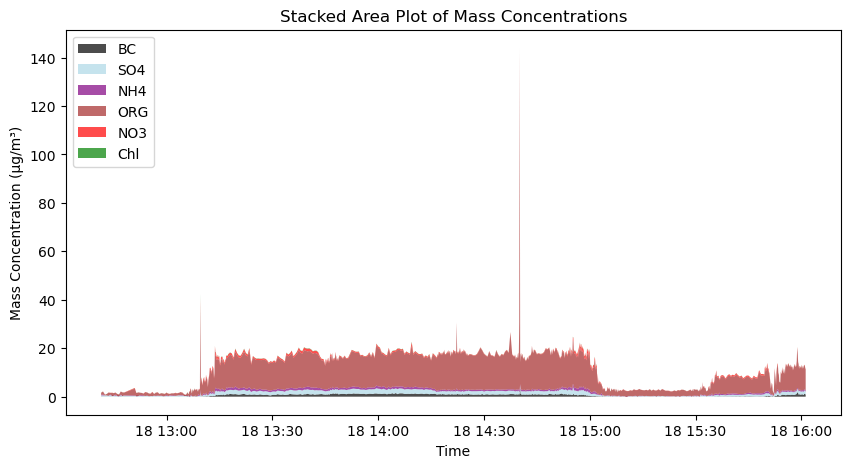

In [19]:
area_time,data_mass_concentration = Area_plot(ds_sp2,ds_ams,ds_height)
#labels = ["BC", "SO4", "NH4", "ORG", "NO3", "Chl"]
#colors = ["black", "blue", "green", "orange", "red", "purple"]  # Assign colors
labels = ["BC", "SO4", "NH4", "ORG", "NO3", "Chl"]
colors = ["black", "lightblue", "purple", "brown", "red", "green"]
# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.stackplot(area_time, data_mass_concentration, labels=labels, colors=colors, alpha=0.7)

# Labels and legend
ax.set_xlabel("Time")
ax.set_ylabel("Mass Concentration (µg/m³)")
ax.set_title("Stacked Area Plot of Mass Concentrations")
ax.legend(loc="upper left")

plt.show()

In [20]:
data_mass_concentration

[array([5.90434e-02, 3.55972e-02, 4.02541e-02, 2.69702e-02, 7.14249e-03,
        3.81426e-02, 1.55635e-02, 2.29073e-02, 3.77151e-02, 2.50376e-02,
        2.60255e-02, 9.24601e-02, 2.34320e-02, 4.62540e-02, 1.70762e-02,
        1.28489e-02, 2.59006e-02, 1.04160e-02, 5.11245e-03, 2.16858e-02,
        1.47699e-02, 1.03282e-02, 8.55517e-03, 8.77649e-03, 2.33258e-02,
        1.02822e-02, 6.15536e-03, 8.45350e-03, 2.45896e-02, 1.15295e-02,
        7.34228e-03, 4.74066e-03, 2.37008e-02, 2.37127e-02, 9.07359e-03,
        1.64807e-02, 9.62999e-03, 1.37543e-02, 7.14960e-03, 5.25448e-02,
        6.64146e-03, 9.80542e-03, 1.64530e-02, 2.44036e-02, 1.86246e-01,
        9.66065e-03, 7.96487e-03, 2.63258e-02, 8.03005e-03, 5.17252e-03,
        8.37259e-03, 1.26796e-02, 1.34905e-02, 6.74636e-03, 7.95075e-03,
        2.52678e-03, 3.30306e-02, 1.39203e-02, 7.17091e-03, 1.19647e-02,
        1.53062e-01, 2.74532e-02, 1.56840e-02, 8.55092e-03, 3.69813e-02,
        1.82944e-02, 1.82670e-02, 1.82484e-02, 2.71

In [21]:
data_mass_concentration[3]

<xarray.DataArray 'ORG' (time: 773)> Size: 6kB
array([  0.789737,   1.23333 ,   0.276286,   0.513671,   1.31379 ,
         0.600173,   1.27837 ,   1.05838 ,   0.846174,   0.903942,
         0.749647,   1.24468 ,   1.49693 ,   1.14669 ,   2.80899 ,
         1.24951 ,   1.49432 ,   1.08775 ,   0.981123,   0.747173,
         1.58378 ,   1.25048 ,   1.13491 ,   0.892778,   1.60486 ,
         0.658337,   1.29651 ,   1.2606  ,   0.751913,   0.931756,
         1.1131  ,   0.863435,   0.991036,   0.885419,   0.502389,
         0.932157,   0.778937,   1.10395 ,   0.932388,   0.947603,
         1.27299 ,   0.933994,   0.728375,   0.429526,   1.4383  ,
         0.421   ,   0.905724,   1.69366 ,   1.87232 ,   2.36662 ,
         2.53778 ,   2.65953 ,   1.01087 ,   1.01027 ,   2.18566 ,
         2.87966 ,   1.95168 ,   2.50773 ,   2.57002 ,   3.00484 ,
         2.39956 ,   2.32848 ,   2.7509  ,   2.82136 ,   2.59828 ,
         2.37931 ,   1.54241 ,   1.96781 ,   1.96126 ,   2.57678 ,
         2.33307 ,  35.1064  ,   4.52169 ,   7.15524 ,   5.82725 ,
         4.30428 ,   4.26453 ,   5.40876 ,   5.86256 ,   6.15394 ,
         4.84618 ,   5.61605 ,   4.67264 ,   6.83879 ,   5.90411 ,
         6.41566 ,   5.18913 ,   3.48718 ,   5.09585 ,   6.26276 ,
         6.95916 ,   8.79419 ,   9.20003 ,   8.54173 ,   8.60325 ,
         7.98194 ,   9.05596 ,   9.61349 ,   9.16257 ,   8.93131 ,
...
         6.70323 ,   5.85948 ,   5.6791  ,   6.86399 ,   6.07445 ,
         6.07084 ,   8.87031 ,   7.38264 ,   7.33445 ,   6.92093 ,
         9.27938 ,   8.50333 ,   9.40638 ,   8.93921 ,   8.65486 ,
        10.5664  ,   9.85711 ,   8.6664  ,   8.6896  ,   7.66196 ,
         7.3611  ,   5.83647 ,   4.358   ,   2.52883 ,   3.59766 ,
         4.54812 ,   3.8615  ,   1.89813 ,   1.33874 ,   0.861569,
         4.46682 ,   8.91266 ,   7.42104 ,   5.85191 ,   3.53226 ,
         7.4627  ,   9.15428 ,  10.1604  ,   9.4667  ,   7.14158 ,
         6.53914 ,   4.31768 ,   4.72783 ,   4.28198 ,   7.72974 ,
         7.12205 ,   7.26705 ,   9.07665 ,   7.78295 ,   8.878   ,
         7.5432  ,   7.08331 ,   8.70796 ,   6.78023 ,  10.9394  ,
         9.52554 ,  10.5293  ,  10.5473  ,   9.83961 ,  10.305   ,
        10.8917  ,  10.6296  ,  10.1988  ,  10.0229  ,   9.85235 ,
        10.4872  ,  10.103   ,   9.45349 ,  10.1763  ,   9.78167 ,
         8.71516 ,   9.28376 ,  10.0155  ,  10.623   ,  10.6422  ,
         9.80476 ,   9.74648 ,   9.9065  ,  11.5572  ,  16.6016  ,
        14.4017  ,  10.7724  ,  10.5985  ,   8.84343 ,   9.69831 ,
         9.47843 ,   9.77375 ,   9.0182  ,  10.3155  ,   9.18495 ,
         9.99135 ,   8.86845 ,   9.06823 ,   9.98517 ,   9.82107 ,
        10.0547  ,   8.98338 ,   8.84577 ])
Coordinates:
  * time      (time) int64 6kB 0 1 2 3 4 5 6 7 ... 766 767 768 769 770 771 772
    datetime  (time) datetime64[ns] 6kB 2012-09-18T12:41:28 ... 2012-09-18T16...

In [22]:
org = data_mass_concentration[3]
org_ressampled = org.resample(datetime="1min").mean()
org_ressampled

<xarray.DataArray 'ORG' (time: 201)> Size: 2kB
array([ 0.789737  ,  0.754808  ,  0.9137305 ,  0.9392715 ,  0.952277  ,
        0.8267945 ,  1.370805  ,  1.14669   ,         nan,         nan,
        2.02925   ,  1.291035  ,  0.864148  ,  1.41713   ,  1.013844  ,
        1.1315985 ,  1.278555  ,  0.8418345 ,  0.9882675 ,  0.9382275 ,
        0.717273  ,  0.9414435 ,  0.9399955 ,  1.103492  ,  0.5789505 ,
        1.73686675,  2.01655571,  2.4781425 ,  7.94603571,  5.28544375,
        5.37190857,  8.1748775 , 10.19088   , 12.32335   , 11.56572857,
       11.4352375 , 12.4317    , 13.372     , 13.0995    , 13.1164    ,
       13.0548    , 14.2944    , 14.2083    , 11.56275   , 12.19586667,
       11.8416    , 12.25435   , 11.9972    , 11.4364    , 11.30816667,
       12.7526    , 12.0823    , 11.4751    , 13.5748    , 13.9713    ,
       12.9842    , 14.92085   , 14.36155   , 15.2108    , 14.70375   ,
       14.29855   , 14.28725   , 13.1524    , 11.81655   , 11.32037875,
       12.1432375 , 12.22611429, 11.78973333, 12.866     , 12.4171    ,
       12.0983    , 14.02775   , 14.23895   , 14.1071    , 13.22905   ,
       12.8489    , 13.4489    , 13.34485   , 14.34645   , 15.6996    ,
       13.5471    , 13.0735    , 14.4361    , 14.29605   , 14.7282    ,
       14.9739    , 14.23745   , 14.00415   , 15.2225    , 13.76525   ,
       13.5188    , 13.45115   , 12.56555   , 12.9682    , 12.7343    ,
       13.86482   , 14.98764286, 15.0098625 , 15.01191429, 15.1569375 ,
...
       14.46545   , 14.12795   , 15.1231    , 16.66835   , 14.52255   ,
       14.57735   , 13.95755   , 14.73435   , 13.90955   , 14.30595   ,
       15.8758    , 19.13195   , 13.96706   , 13.34995714, 30.77414875,
       12.81312857, 13.0309375 , 15.3876    , 15.821     , 14.59625   ,
       14.69545   , 16.1406    , 16.7021    , 15.40636   , 15.9573    ,
       13.31251667, 13.8425    , 13.93694286, 14.48525   , 15.25964286,
       13.8241125 , 15.52991429, 13.03115   , 13.93918571, 10.23216375,
       10.78421857,  5.66374875,  3.40976143,  2.24873   ,  2.68655429,
        2.52679875,  2.27382714,  2.18842333,  2.44720333,  2.29142   ,
        2.174665  ,  2.52164   ,  2.460005  ,  2.66099   ,  2.378085  ,
        2.38351   ,  2.57007   ,  2.37542   ,  2.50632   ,  2.583265  ,
        2.40092   ,  2.14589   ,  1.99841   ,  2.295315  ,  2.413605  ,
        2.524245  ,  2.17986   ,  2.298045  ,  2.41849   ,  2.42300625,
        2.84579429,  2.89778   ,  2.57269714,  4.317985  ,  6.47137571,
        6.4863025 ,  7.08832   ,  6.70022   ,  7.247995  ,  7.076745  ,
        7.40544   ,  7.00445   ,  6.643205  ,  6.574775  ,  6.281355  ,
        6.271545  ,  6.072645  ,  8.126475  ,  8.39728   ,  8.77963286,
        3.80410143,  4.98096237,  7.35823   ,  7.4602025 ,  9.15900571,
       10.278395  ,  9.64698286, 11.66043   ,  9.74043143,  9.6611775 ,
        8.914575  ])
Coordinates:
  * time     (time) datetime64[ns] 2kB 2012-09-18T12:41:00 ... 2012-09-18T16:...

In [23]:
ds_height_resampled = ds_height.resample(Time="1min").mean()
ds_height_resampled

<xarray.Dataset> Size: 5MB
Dimensions:         (data_point: 431, sps32: 32, sps04: 4, sps01: 1, sps02: 2,
                     sps64: 64)
Coordinates:
  * data_point      (data_point) datetime64[ns] 3kB 2012-09-18T08:52:00 ... 2...
Dimensions without coordinates: sps32, sps04, sps01, sps02, sps64
Data variables: (12/140)
    IAS_RVSM        (data_point, sps32) float32 55kB 0.0 0.0 0.0 ... 11.9 11.87
    IAS_RVSM_FLAG   (data_point, sps32) float32 55kB 3.0 3.0 3.0 ... 0.0 0.0 0.0
    TAS_RVSM        (data_point, sps32) float32 55kB 0.0 0.0 0.0 ... 12.33 12.3
    TAS_RVSM_FLAG   (data_point, sps32) float32 55kB 3.0 3.0 3.0 ... 1.0 1.0 1.0
    TAT_DI_R        (data_point, sps32) float32 55kB 0.0 0.0 0.0 ... 306.2 306.2
    TAT_DI_R_FLAG   (data_point, sps32) float32 55kB 3.0 3.0 3.0 ... 1.0 1.0 1.0
    ...              ...
    TDEW_C_U        (data_point, sps01) float32 2kB nan nan ... 0.3841 0.4042
    TDEW_C_U_FLAG   (data_point, sps01) float32 2kB 3.0 3.0 3.0 ... 0.0 0.0 0.0
    U_NOTURB        (data_point, sps01) float32 2kB nan nan ... 0.6499 0.2066
    U_NOTURB_FLAG   (data_point, sps01) float32 2kB 3.0 3.0 3.0 ... 0.95 1.273
    V_NOTURB        (data_point, sps01) float32 2kB nan nan ... -2.633 -1.128
    V_NOTURB_FLAG   (data_point, sps01) float32 2kB 3.0 3.0 3.0 ... 0.95 1.273
Attributes: (12/22)
    conventions:         CF-1.0
    title:               Data from b734 on 18-SEP-12
    institution:         FAAM
    source:              FAAM BAe-146 Aircraft Data
    references:          http://www.faam.ac.uk
    Cal_Input_Files:     Input files:\n/home/tardis/data/fltcons/flight-cst_f...
    ...                  ...
    Tardis_Version:      v004
    Format_Version:      1.00
    comment:             FAAM data core_faam_yyyymmdd_vnnn_rn_cnnn.nc\n where...
    Data_Date:           20130619
    TimeInterval:        08:52:02-16:02:21
    History:             Dataset /home/tardis/data/ncdata/core_faam_20120918_...

In [24]:
common_times = np.intersect1d(ds_height_resampled['data_point'], org_ressampled["time"])

    
org_ressampled_matched = org_ressampled.sel(time=common_times)
ds_height_matched = ds_height_resampled.sel(data_point=common_times)

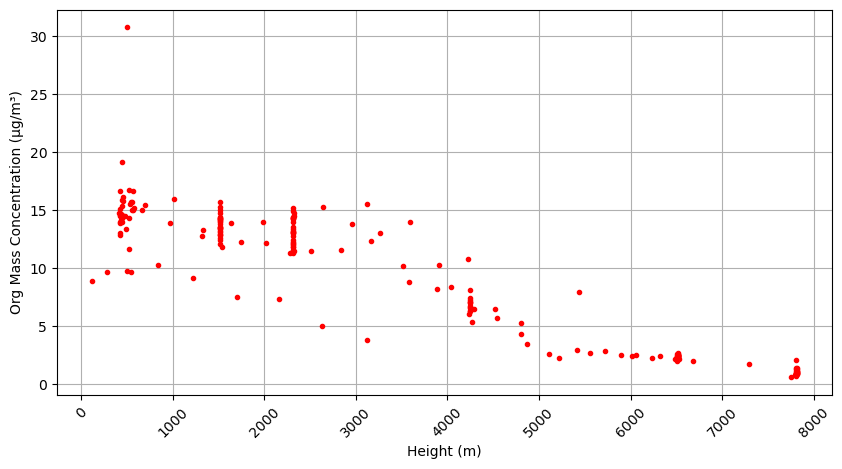

In [25]:
plt.figure(figsize=(10, 5))
plt.plot(ds_height_matched['GPS_ALT'], org_ressampled_matched, color="r", marker='.',linewidth=0)
#plt.xlim(filtered_ds_psap['Time'][550],filtered_ds_psap['Time'][3000])
#plt.ylim(100,1000)
# Formatting
plt.xlabel("Height (m)")
plt.ylabel("Org Mass Concentration (µg/m³)")
#plt.title("Mass absortion efficiency Over Time")
plt.xticks(rotation=45)
plt.grid()

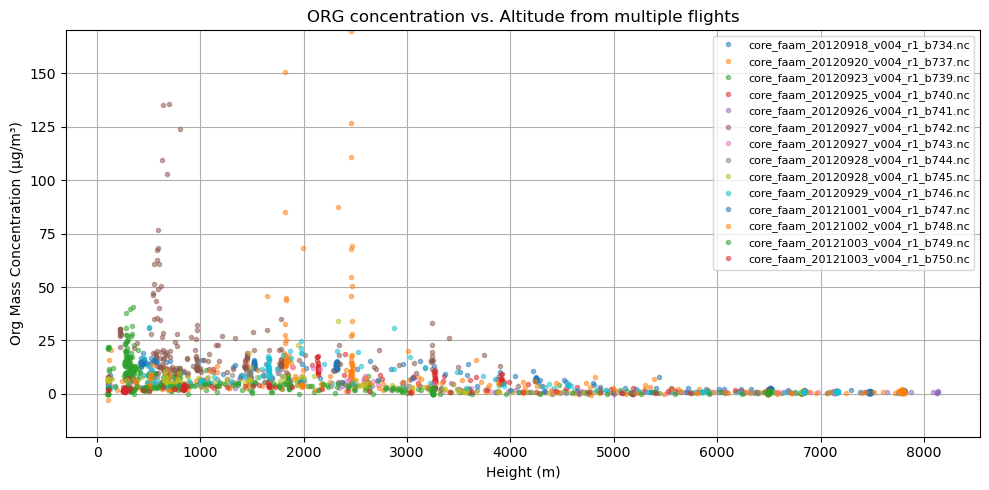

In [26]:

plt.figure(figsize=(10, 5))

# Iterate over all matching flights
for sp2_file, ams_file, nc_file, neph_file in zip(filtered_sp2, filtered_ams, filtered_nc, filtered_neph):

    ds_sp2,ds_ams,ds_neph = dataset_sp2_ams_neph(sp2_file,ams_file,neph_file)
    area_time,data_mass_concentration = Area_plot(ds_sp2,ds_ams,ds_height)

    org = data_mass_concentration[3]
    org_ressampled = org.resample(datetime="1min").mean()

    ds_height = xr.open_dataset(nc_file)
    ds_height_resampled = ds_height.resample(Time="1min").mean()

    # Apply filter 
    common_times = np.intersect1d(ds_height_resampled['data_point'], org_ressampled["time"])
    org_ressampled_matched = org_ressampled.sel(time=common_times)
    ds_height_matched = ds_height_resampled.sel(data_point=common_times)


    # Plot
    plt.plot(
        ds_height_matched['GPS_ALT'],
        org_ressampled_matched,
        marker=".",
        linewidth=0,
        alpha=0.5,
        label=nc_file.split("/")[-1]  # Optional: show filename as label
    )

# Formatting
plt.xlabel("Height (m)")
plt.ylabel("Org Mass Concentration (µg/m³)")
plt.ylim(-20,170)
plt.grid()
plt.legend(loc="best", fontsize=8)
plt.title("ORG concentration vs. Altitude from multiple flights")
plt.tight_layout()
plt.show()
    

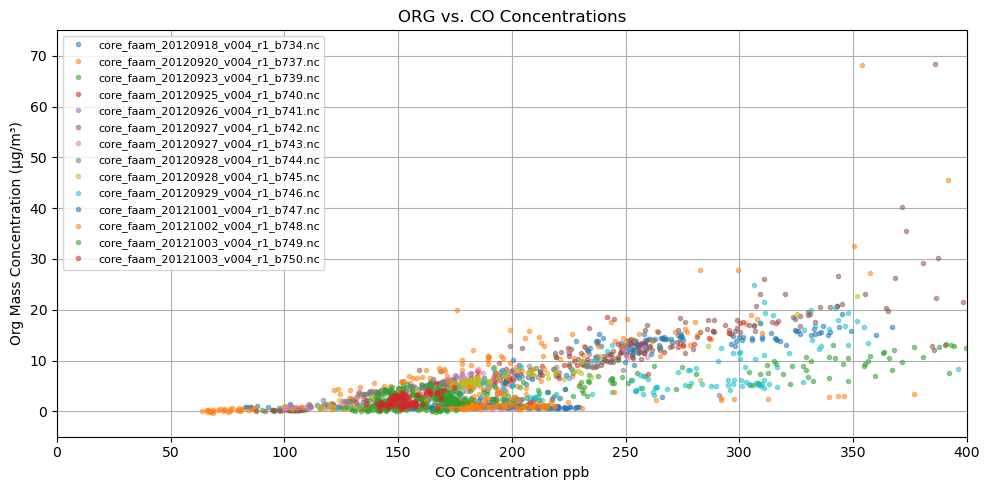

In [27]:

plt.figure(figsize=(10, 5))

# Iterate over all matching flights
for sp2_file, ams_file, nc_file, neph_file in zip(filtered_sp2, filtered_ams, filtered_nc, filtered_neph):

    ds_sp2,ds_ams,ds_neph = dataset_sp2_ams_neph(sp2_file,ams_file,neph_file)
    area_time,data_mass_concentration = Area_plot(ds_sp2,ds_ams,ds_height)

    org = data_mass_concentration[3]
    org_ressampled = org.resample(datetime="1min").mean()

    ds_CO = xr.open_dataset(nc_file)
    ds_CO_resampled = ds_CO.resample(Time="1min").mean()

    valid_CO = ds_CO_resampled["CO_AERO_FLAG"] == 0
    filtered_CO = ds_CO_resampled.where(valid_CO, drop=True)

    # Apply filter 
    common_times = np.intersect1d(filtered_CO['data_point'], org_ressampled["time"])
    org_ressampled_matched = org_ressampled.sel(time=common_times)
    filtered_CO_matched = filtered_CO.sel(data_point=common_times)


    # Plot
    plt.plot(
        filtered_CO_matched['CO_AERO'],
        org_ressampled_matched,
        marker=".",
        linewidth=0,
        alpha=0.5,
        label=nc_file.split("/")[-1]  # Optional: show filename as label
    )

# Formatting
plt.xlabel("CO Concentration ppb")
plt.ylabel("Org Mass Concentration (µg/m³)")
plt.ylim(-5,75)
plt.xlim(0,400)
plt.grid()
plt.legend(loc="best", fontsize=8)
plt.title("ORG vs. CO Concentrations")
plt.tight_layout()
plt.show()